# **Week 4: Predictive Modeling and Optimization in Logistics Systems**

## **Project Title**

**Logistics Delivery Performance Analysis and Strategic Planning Using Python**

## **Objective**

This notebook focuses on applying predictive modeling and optimization concepts to a logistics problem using Python. The objective is to develop machine-learning models that can predict delivery time based on logistics-related factors such as shipment volume, transportation distance, transportation mode, and region.

Two predictive models, Linear Regression and Decision Tree Regression, will be implemented and evaluated using appropriate performance metrics including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²). The models will then be compared to identify the better-performing approach.

Based on the predictive analysis, optimization strategies will be proposed to improve delivery efficiency, transportation planning, resource allocation, and operational performance.

# **Notebook Contents**

1. **Objective**
2. **Problem Definition**
3. **Dataset Simulation and Description**
4. **Python Environment Setup**
5. **Hypothetical Dataset Generation**
6. **Initial Data Inspection**
7. **Data Preparation**
8. **Feature and Target Selection**
9. **Categorical Variable Encoding**
10. **Train-Test Split**
11. **Model Selection**
12. **Linear Regression Model**
13. **Decision Tree Regression Model**
14. **Model Evaluation**
15. **Model Comparison**
16. **Best Model Selection**
17. **Prediction Analysis**
18. **Optimization Strategies**
19. **Business Recommendations**
20. **Key Findings**
21. **Future Scope**
22. **Conclusion**

# **1. Problem Definition**

## **Logistics Prediction Problem**

Delivery time is an important logistics performance metric because delays can negatively affect customer satisfaction, transportation planning, and operational efficiency.

The objective of this predictive modeling task is to predict the number of days required to deliver a shipment using logistics-related features.

## **Target Variable**

The target variable is:

**delivery_time_days**

## **Predictor Variables**

The predictive models will use the following features:

- shipment_volume
- distance_km
- region
- transport_mode

The model will learn relationships between these variables and historical delivery time in the simulated dataset.

## **Business Objective**

Accurate delivery-time prediction can help logistics managers identify shipments that may require additional attention, improve transportation planning, allocate resources more effectively, and reduce potential delivery delays.

# **2. Dataset Simulation and Description**

A hypothetical logistics dataset is generated using Python to simulate shipment operations. The dataset represents 500 shipment records containing information about shipment volume, transportation distance, transportation mode, geographic region, delivery time, transportation cost, and on-time delivery status.

The dataset is simulated because this task focuses on demonstrating the predictive modeling workflow rather than using confidential operational data.

The dataset is designed to contain realistic relationships between logistics variables so that predictive models can be trained and evaluated.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Python environment is ready...")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python environment is ready...
Pandas version: 2.2.3
NumPy version: 2.1.3


In [2]:
np.random.seed(42)

n = 500

logistics_data = pd.DataFrame({
    "shipment_id": [f"SHP{i:04d}" for i in range(1, n + 1)],
    "region": np.random.choice(
        ["North", "South", "East", "West"],
        size=n
    ),
    "transport_mode": np.random.choice(
        ["Road", "Rail", "Air", "Sea"],
        size=n,
        p=[0.45, 0.25, 0.15, 0.15]
    ),
    "shipment_volume": np.random.randint(
        10, 501, size=n
    ),
    "distance_km": np.random.randint(
        50, 2001, size=n
    )
})

logistics_data["delivery_time_days"] = (
    2
    + logistics_data["distance_km"] / 400
    + np.random.normal(0, 1.5, n)
).round(1)

logistics_data["delivery_time_days"] = (
    logistics_data["delivery_time_days"].clip(lower=1)
)

logistics_data["transportation_cost"] = (
    500
    + logistics_data["distance_km"] * 2
    + logistics_data["shipment_volume"] * 8
    + np.random.normal(0, 1000, n)
).round(2)

logistics_data["transportation_cost"] = (
    logistics_data["transportation_cost"].clip(lower=500)
)

logistics_data["on_time"] = (
    logistics_data["delivery_time_days"] <= 7
)

print("Dataset created successfully!")
print("Rows:", logistics_data.shape[0])
print("Columns:", logistics_data.shape[1])

display(logistics_data.head())

Dataset created successfully!
Rows: 500
Columns: 8


,shipment_id,region,transport_mode,shipment_volume,distance_km,delivery_time_days,transportation_cost,on_time
0,SHP0001,East,Road,444,96,2.2,4468.68,True
1,SHP0002,West,Road,207,1361,3.7,5810.59,True
2,SHP0003,North,Sea,143,827,6.3,1879.63,True
3,SHP0004,East,Road,76,1089,6.0,1525.19,True
4,SHP0005,East,Road,400,760,3.6,3694.34,True


# **3. Initial Data Inspection**

The dataset is inspected before model development to verify its structure, variables, data types, and observations. This step ensures that the dataset is suitable for machine-learning preprocessing.

In [3]:
print("Dataset Shape:", logistics_data.shape)

print("\nColumn Names:")
print(logistics_data.columns.tolist())

print("\nData Types:")
print(logistics_data.dtypes)

print("\nMissing Values:")
print(logistics_data.isnull().sum())

Dataset Shape: (500, 8)

Column Names:
['shipment_id', 'region', 'transport_mode', 'shipment_volume', 'distance_km', 'delivery_time_days', 'transportation_cost', 'on_time']

Data Types:
shipment_id             object
region                  object
transport_mode          object
shipment_volume          int64
distance_km              int64
delivery_time_days     float64
transportation_cost    float64
on_time                   bool
dtype: object

Missing Values:
shipment_id            0
region                 0
transport_mode         0
shipment_volume        0
distance_km            0
delivery_time_days     0
transportation_cost    0
on_time                0
dtype: int64


# **4. Feature and Target Selection**

The target variable for the predictive modeling task is `delivery_time_days`.

The predictor variables are `shipment_volume`, `distance_km`, `region`, and `transport_mode`.

The shipment ID is excluded because it is only an identifier and does not provide useful predictive information.

In [4]:
features = [
    "shipment_volume",
    "distance_km",
    "region",
    "transport_mode"
]

target = "delivery_time_days"

X = logistics_data[features]
y = logistics_data[target]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,shipment_volume,distance_km,region,transport_mode
0,444,96,East,Road
1,207,1361,West,Road
2,143,827,North,Sea
3,76,1089,East,Road
4,400,760,East,Road



Target:


,delivery_time_days
0,2.2
1,3.7
2,6.3
3,6.0
4,3.6


# **5. Categorical Variable Encoding**

Machine-learning models require numerical input. The `region` and `transport_mode` variables are categorical, so they are converted into numerical representations using one-hot encoding.

One-hot encoding creates separate binary columns for each category while avoiding an artificial numerical ranking between categories.

In [5]:
X_encoded = pd.get_dummies(
    X,
    columns=["region", "transport_mode"],
    drop_first=True
)

print("Encoded feature dataset:")
display(X_encoded.head())

print("\nEncoded dataset shape:", X_encoded.shape)

Encoded feature dataset:


,shipment_volume,distance_km,region_North,region_South,region_West,transport_mode_Rail,transport_mode_Road,transport_mode_Sea
0,444,96,False,False,False,False,True,False
1,207,1361,False,False,True,False,True,False
2,143,827,True,False,False,False,False,True
3,76,1089,False,False,False,False,True,False
4,400,760,False,False,False,False,True,False



Encoded dataset shape: (500, 8)


# **6. Train-Test Split**

The dataset is divided into training and testing sets. The training data is used to train the predictive models, while the testing data is used to evaluate how well the models perform on unseen observations.

An 80:20 split is used, with 80% of the data allocated for training and 20% for testing.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


# **7. Linear Regression Model**

Linear Regression is used as a baseline predictive model. It estimates the relationship between the predictor variables and delivery time.

Linear Regression is useful as a starting point because it is simple, interpretable, and provides a benchmark against which more flexible models can be compared.

In [7]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


# **8. Decision Tree Regression Model**

A Decision Tree Regressor is used as a second predictive model. Decision trees can capture nonlinear relationships and interactions between variables.

This makes the model useful for logistics data where relationships between distance, shipment volume, transportation mode, and delivery time may not always be purely linear.

In [8]:
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


# **9. Model Evaluation**

The predictive models are evaluated using three commonly used regression metrics:

### **Mean Absolute Error (MAE)**

MAE measures the average absolute difference between actual and predicted delivery times. Lower values indicate better performance.

### **Root Mean Squared Error (RMSE)**

RMSE measures prediction error while giving greater weight to larger errors. Lower values indicate better performance.

### **R-squared (R²)**

R² indicates how much of the variation in the target variable is explained by the model. Values closer to 1 generally indicate better explanatory performance.

In [9]:
def evaluate_model(model_name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = pd.DataFrame([
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    ),
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_predictions
    )
])

display(results)

,Model,MAE,RMSE,R2
0,Linear Regression,1.169429,1.473648,0.386905
1,Decision Tree,1.397820,1.763785,0.121723


# **10. Model Comparison**

The performance of the Linear Regression and Decision Tree models is compared using MAE, RMSE, and R².

For MAE and RMSE, lower values indicate better predictive accuracy. For R², a higher value indicates that the model explains more variation in delivery time.

The model with the strongest overall evaluation results will be selected as the preferred model for the logistics prediction task.

In [10]:
best_model_row = results.loc[
    results["RMSE"].idxmin()
]

print("Best Model Based on RMSE:")
print(best_model_row)

Best Model Based on RMSE:
Model    Linear Regression
MAE               1.169429
RMSE              1.473648
R2                0.386905
Name: 0, dtype: object


# **11. Prediction Analysis**

Actual and predicted delivery times are compared to understand how closely the selected model's predictions match the observed values.

A scatter plot is used to visualize the relationship between actual and predicted delivery times.

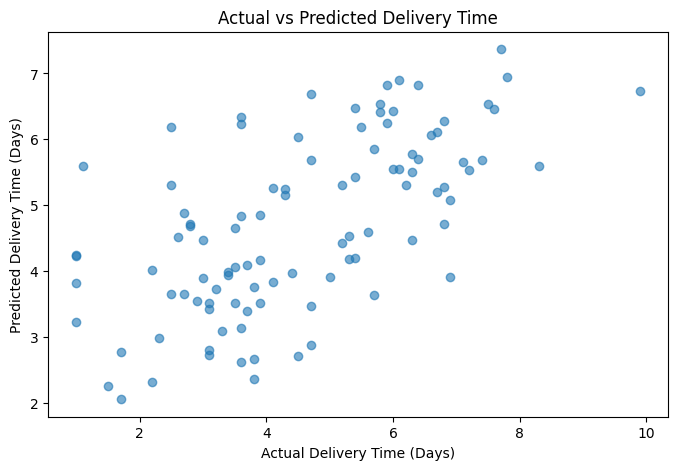

In [11]:
best_model_name = best_model_row["Model"]

if best_model_name == "Linear Regression":
    best_predictions = linear_predictions
else:
    best_predictions = tree_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

plt.xlabel("Actual Delivery Time (Days)")
plt.ylabel("Predicted Delivery Time (Days)")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

# **12. Optimization Strategies**

Predictive modeling can support logistics optimization by identifying factors associated with delivery time and allowing logistics managers to make proactive decisions.

The following optimization strategies are proposed:

### **1. Route Planning**

Distance should be considered when planning transportation routes because longer distances can contribute to increased delivery time.

### **2. Transportation Mode Selection**

Transportation modes can be selected according to delivery requirements, shipment characteristics, distance, and cost.

### **3. Resource Allocation**

Regions and shipment categories associated with higher delivery times can receive additional operational resources.

### **4. High-Risk Shipment Monitoring**

Predicted delivery times can be used to identify shipments that may require additional monitoring or early intervention.

### **5. Capacity Planning**

Shipment volume can be considered when allocating transportation capacity to prevent operational bottlenecks.

### **6. Cost-Efficient Logistics Planning**

Predicted delivery performance can be combined with transportation-cost information to balance service quality and operational expenditure.

# **13. Business Recommendations**

Based on the predictive modeling workflow, the following recommendations are proposed:

- Use delivery-time predictions to identify potentially delayed shipments before they become major operational issues.
- Consider transportation distance when planning routes and delivery schedules.
- Select transportation modes based on delivery urgency, shipment characteristics, distance, and cost.
- Allocate additional resources to regions or shipment categories showing higher delivery-time risk.
- Use shipment-volume information for transportation and warehouse capacity planning.
- Continuously monitor model performance and retrain predictive models when new logistics data becomes available.
- Combine predictive analytics with route and resource optimization techniques for more efficient logistics operations.

# **14. Key Findings**

The Week 4 predictive modeling analysis demonstrates how machine-learning techniques can be applied to logistics delivery-time prediction.

The main findings include:

- Delivery time can be modeled using logistics-related variables such as shipment volume, distance, region, and transportation mode.
- Linear Regression provides an interpretable baseline for delivery-time prediction.
- Decision Tree Regression provides a more flexible approach for capturing nonlinear relationships.
- MAE, RMSE, and R² provide useful measures for comparing predictive model performance.
- Predictive insights can support proactive identification of potentially delayed shipments.
- Model-based insights can contribute to transportation planning, resource allocation, capacity planning, and logistics optimization.

# **15. Future Scope**

Future work can improve the predictive modeling system by using larger and more realistic logistics datasets.

Possible extensions include:

- Random Forest and Gradient Boosting models
- Hyperparameter tuning
- Cross-validation
- Delivery-delay classification
- Shipment-risk prediction
- Transportation-cost prediction
- Route optimization
- Customer segmentation
- Real-time logistics monitoring
- Integration with Power BI or other business-intelligence platforms

These improvements can create a more comprehensive decision-support system for logistics management.

# **16. Conclusion**

This Week 4 project demonstrated the application of predictive modeling and optimization concepts to a logistics problem using Python. A hypothetical logistics dataset was generated and prepared for machine-learning analysis. Delivery time was selected as the target variable, while shipment volume, transportation distance, region, and transportation mode were used as predictive features.

Two regression techniques, Linear Regression and Decision Tree Regression, were implemented and evaluated. Model performance was measured using Mean Absolute Error, Root Mean Squared Error, and R-squared. Comparing these metrics provides a systematic approach for selecting the more suitable predictive model.

The analysis demonstrates that predictive analytics can support logistics decision-making by providing estimates of delivery time and helping identify shipments that may require additional attention. These predictions can be combined with transportation planning, capacity management, route planning, and resource allocation strategies to improve operational efficiency.

Overall, the project demonstrates how predictive modeling can transform logistics data into actionable information. Future work can extend the system using advanced machine-learning algorithms, cross-validation, hyperparameter tuning, real-world logistics data, and optimization algorithms to develop a more comprehensive logistics decision-support solution.